### **1. Importing the required packages**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

### **2. Reading and Exploring the data**

In [ ]:
customers = pd.read_csv('Mall_Customers.csv')

In [ ]:
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
customers.drop(columns = 'CustomerID', inplace = True)

In [ ]:
customers.shape

(200, 4)

In [ ]:
customers.dtypes #print the datatype of the values present in each column

,0
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
customers.isnull().sum() #print the total number of missing values column-wise

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
customers.isnull().sum(axis = 1) #print the total number of missing values row-wise

,0
0,0
1,0
2,0
3,0
4,0
...,...
195,0
196,0
197,0
198,0


In [ ]:
customers.isnull().sum(axis = 1) > 5 #mark all the rows with True which fulfill this given criteria

,0
0,False
1,False
2,False
3,False
4,False
...,...
195,False
196,False
197,False
198,False


In [ ]:
customers[customers.isnull().sum(axis = 1) > 5] #print the rows which have more than 5 missing values

,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [ ]:
customers = customers[customers.isnull().sum(axis = 1) <= 5] #remove the rows which have more than 5 missing values

In [ ]:
#check for duplicates
customers.duplicated().sum()

np.int64(0)

In [ ]:
customers.drop_duplicates(inplace = True)

In [ ]:
#Encoding the Gender column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
customers['Gender'] = le.fit_transform(customers['Gender'])

### **3. Machine Learning Process**

In [ ]:
X = customers.values #'.values' will convert the customers dataframe into an array

#### **Process to perform linkages on the data and represent it as a dendrogram**

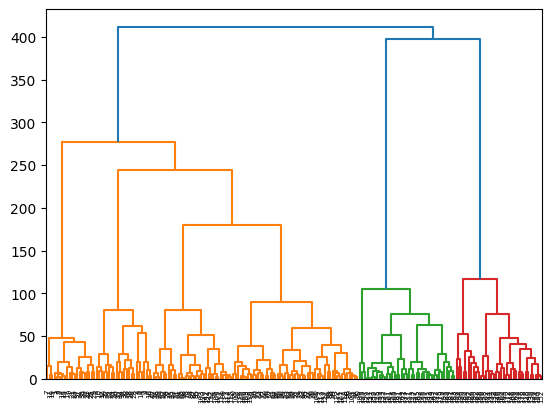

In [ ]:
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))

#### **Apply the Agglomerative Clustering on the Data**

In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters = 3, metric = 'euclidean', linkage = 'ward')

In [ ]:
y = agg_cluster.fit_predict(X) #start making the clusters and will put all the 200 datapoints into these 3 clusters

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

In [ ]:
output = pd.DataFrame(y, columns = ['Cluster Number'])

In [ ]:
final_df = pd.concat([customers, output], axis = 1)

In [ ]:
final_df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Number
0,1,19,15,39,0
1,1,21,15,81,0
2,0,20,16,6,0
3,0,23,16,77,0
4,0,31,17,40,0
...,...,...,...,...,...
195,0,35,120,79,2
196,0,45,126,28,1
197,1,32,126,74,2
198,1,32,137,18,1
